In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import mpltern
import matplotlib.patches as mpatches
from matplotlib.patches import Circle, Rectangle
from scipy.spatial import ConvexHull
from scipy.stats import levene, gaussian_kde, entropy as _entropy


In [2]:
sample_table = pd.read_csv("../data_processed/sample_table.csv", index_col=0)

color_sample_group = {
    'subsurface_sample': "#ad8b56ff",
    'soil': "#85ba89ff",
    'marine_water': "#57a8d1ff",
    'freshwater': "#c2e8e5ff"
}

# pH - Temp

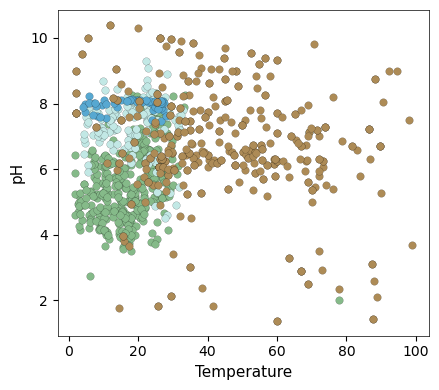

In [3]:
fig, ax = plt.subplots(figsize=(4.5, 4))

for group in ["soil", "freshwater", "marine_water", "subsurface_sample"]: #for the order of dots
    color = color_sample_group[group]

    subset = sample_table[sample_table["sample_group"] == group]
    subset = subset.dropna(subset=["temp", "ph"])

    ax.scatter(
        subset["temp"],
        subset["ph"],
        s=30,
        color=color,
        alpha=1,
        label=group,
        edgecolor="black",
        linewidth=0.1
    )

ax.set_xlabel("Temperature", fontsize=11)
ax.set_ylabel("pH", fontsize=11)

for spine in ax.spines.values():
    spine.set_linewidth(0.5)


plt.tight_layout()
plt.savefig("../outputs/ph_temp_small_dots.svg", format="svg", transparent=True)

plt.show()


In [4]:

sample_group = ["soil", "freshwater", "marine_water", "subsurface_sample"]

# Global range for normalisation (all groups pooled)
_valid = sample_table[["ph", "temp"]].dropna()
_ph_min, _ph_max = _valid["ph"].min(),   _valid["ph"].max()
_t_min,  _t_max  = _valid["temp"].min(), _valid["temp"].max()

def _hull_frac_pt(ph_arr, tmp_arr):
    pts = np.column_stack([(ph_arr - _ph_min) / (_ph_max - _ph_min),
                           (tmp_arr - _t_min)  / (_t_max  - _t_min)])
    pts = pts[~np.isnan(pts).any(axis=1)]
    if len(np.unique(pts, axis=0)) < 3:
        return np.nan
    try:
        return ConvexHull(pts).volume  # area in 2-D
    except Exception:
        return np.nan

print(f"{'Group':<22} {'n_pH':>5} {'pH mean±SD':>13} {'pH range':>12}  "
      f"{'n_T':>5} {'T mean±SD':>13} {'T range':>12}  {'Hull%':>6}")
print("─" * 100)
for g in sample_group:
    d   = sample_table[sample_table["sample_group"] == g]
    ph  = d["ph"].dropna();   tmp = d["temp"].dropna()
    d2  = d.dropna(subset=["ph", "temp"])
    h   = _hull_frac_pt(d2["ph"].values, d2["temp"].values)
    print(f"  {g:<20} {len(ph):>5} {ph.mean():>5.2f}±{ph.std():.2f}  "
          f"[{ph.min():.1f}–{ph.max():.1f}]  "
          f"{len(tmp):>5} {tmp.mean():>5.1f}±{tmp.std():.1f}  "
          f"[{tmp.min():.0f}–{tmp.max():.0f}]  "
          f"{h*100:>5.1f}%")

# Levene test: unequal variance across groups
ph_vecs = [sample_table[sample_table["sample_group"]==g]["ph"].dropna().values
           for g in sample_group]
t_vecs  = [sample_table[sample_table["sample_group"]==g]["temp"].dropna().values
           for g in sample_group]
lev_ph = levene(*[v for v in ph_vecs  if len(v) > 1])
lev_t  = levene(*[v for v in t_vecs   if len(v) > 1])
print(f"\n  Levene test pH  (equal variance): W={lev_ph.statistic:.1f}, p={lev_ph.pvalue:.2e}")
print(f"  Levene test T°C (equal variance): W={lev_t.statistic:.1f},  p={lev_t.pvalue:.2e}")


Group                   n_pH    pH mean±SD     pH range    n_T     T mean±SD      T range   Hull%
────────────────────────────────────────────────────────────────────────────────────────────────────
  soil                   378  5.55±1.12  [2.0–8.3]    377  17.4±8.3  [2–78]   42.8%
  freshwater             153  7.34±0.83  [4.5–9.3]    163  18.8±7.5  [4–33]   11.3%
  marine_water            56  7.96±0.18  [7.5–8.2]    161  15.6±9.6  [-1–31]    1.6%
  subsurface_sample      389  6.75±1.75  [1.4–10.4]    392  43.7±21.2  [2–99]   85.8%

  Levene test pH  (equal variance): W=40.6, p=1.01e-24
  Levene test T°C (equal variance): W=130.8,  p=2.30e-72


# Additional variables

In [5]:
# Note; ORP vs pH reference ranges:
#
# Marine surface water:
# pH 7.8–8.3 | Eh +100 to +350 mV
# (Stumm & Morgan 1996; Millero 2013)
#
# Freshwater (oxygenated rivers/lakes):
# pH 6.0–9.0 | Eh +100 to +500 mV
# (Stumm & Morgan 1996; Appelo & Postma 2005)
#
# Aerobic soils:
# pH 4.0–8.5 | Eh +200 to +700 mV
# (Vepraskas & Faulkner 2001; Reddy & DeLaune 2008)
#
# Note: apply to oxygenated/aerobic conditions only.. Anoxic (stratified waters, waterlogged soils) can reach -200 mV or below

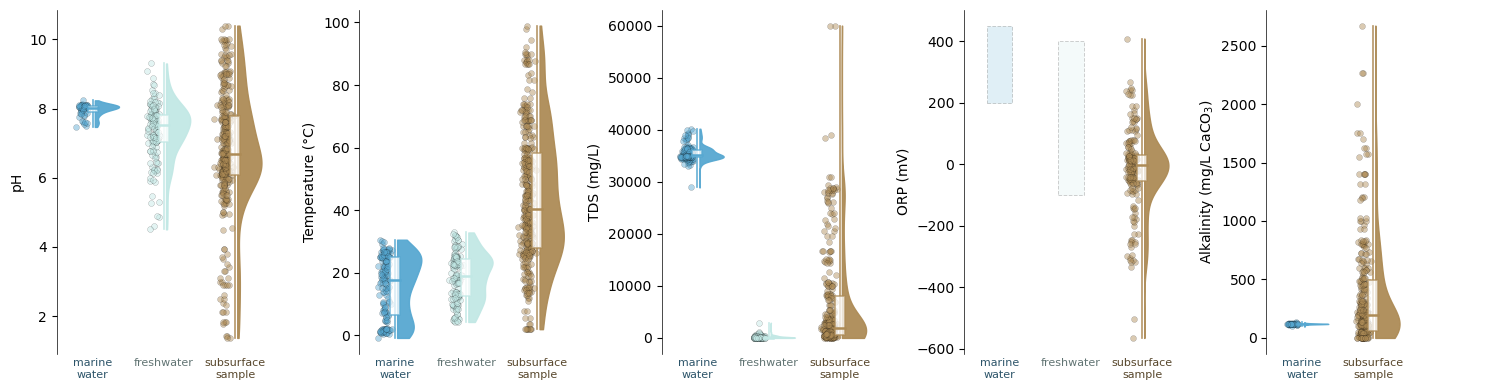

In [6]:
fig, axes = plt.subplots(1, 5, figsize=(15, 4))
fig.patch.set_facecolor("white")

vars_viol = [
    ("ph",      "pH",                            False),
    ("temp",    "Temperature (°C)",              False),
    ("tds",     "TDS (mg/L)",                    False),
    ("orp",     "ORP (mV)",                      False),
    ("alk_tot", "Alkalinity (mg/L CaCO$_3$)",    False),
]

groups_viol = ["marine_water", "freshwater", "subsurface_sample"]

label_dict = {
    "marine_water":      "marine\nwater",
    "freshwater":        "freshwater",
    "subsurface_sample": "subsurface\nsample",
}

orp_ranges = {
    "freshwater":   (-100, 400),
    "marine_water": (200, 450),
}

rng = np.random.default_rng(0)

for ax, (var, ylabel, do_log) in zip(axes, vars_viol):
    ax.set_facecolor("white")

    if var == "alk_tot":
        groups_this = ["marine_water", "subsurface_sample"]
    else:
        groups_this = groups_viol

    positions = np.arange(len(groups_this))

    if var == "orp":
        for i, group in enumerate(groups_this):
            if group in orp_ranges:
                y0, y1 = orp_ranges[group]
                ax.add_patch(Rectangle(
                    (i - 0.18, y0), 0.36, y1 - y0,
                    facecolor=color_sample_group[group],
                    edgecolor="black",
                    linewidth=0.7,
                    linestyle="--",
                    alpha=0.18,
                    zorder=1,
                ))

    for i, group in enumerate(groups_this):
        y = sample_table.loc[sample_table["sample_group"] == group, var].dropna().values

        if do_log:
            y = np.log10(np.clip(y, 0.01, None))

        if len(y) < 5:
            continue

        x_scatter = rng.normal(loc=i - 0.14, scale=0.04, size=len(y))
        ax.scatter(
            x_scatter, y,
            s=18,
            c=color_sample_group[group],
            edgecolors="black",
            linewidths=0.2,
            alpha=0.45,
            zorder=3,
            rasterized=True,
        )

        if len(np.unique(y)) > 1:
            y_grid = np.linspace(y.min(), y.max(), 300)
            dens = gaussian_kde(y)(y_grid)
            dens = dens / dens.max()

            ax.fill_betweenx(
                y_grid,
                i + 0.03,
                i + 0.03 + 0.34 * dens,
                facecolor=color_sample_group[group],
                edgecolor=color_sample_group[group],
                linewidth=1.0,
                alpha=0.95,
                zorder=2,
            )

        q1, med, q3 = np.percentile(y, [25, 50, 75])

        ax.plot(
            [i, i],
            [y.min(), y.max()],
            color=color_sample_group[group],
            linewidth=1.2,
            alpha=0.9,
            zorder=4,
        )

        ax.add_patch(Rectangle(
            (i - 0.07, q1),
            0.14,
            q3 - q1,
            facecolor="white",
            edgecolor=color_sample_group[group],
            linewidth=1.2,
            alpha=0.75,
            zorder=5,
        ))

        ax.plot(
            [i - 0.07, i + 0.07],
            [med, med],
            color=color_sample_group[group],
            linewidth=1.8,
            zorder=6,
        )

    ax.set_xticks(positions)
    ax.set_xticklabels([label_dict[g] for g in groups_this], fontsize=8)

    for tick, group in zip(ax.get_xticklabels(), groups_this):
        r, g_col, b = mcolors.to_rgb(color_sample_group[group])
        tick.set_color((r * 0.5, g_col * 0.5, b * 0.5))

    ax.set_xlim(-0.5, 2.5)

    ax.set_ylabel(ylabel, fontsize=10)
    ax.spines["bottom"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.5)
    ax.tick_params(axis="x", length=0)

plt.tight_layout()
#plt.savefig("../outputs/environment_violin_plots.svg", format="svg",
#            bbox_inches="tight", dpi=300, transparent=True)
plt.savefig("../outputs/environment_violin_plots.png", format="png",
            bbox_inches="tight", dpi=600)
plt.show()

# Pipper plot

In [7]:
EW = {'SO4': 48.03, 'Cl': 35.45, 'HCO3': 61.02,
      'Ca': 20.04, 'Mg': 12.15, 'Na': 22.99, 'K': 39.10}

water = sample_table[sample_table["sample_group"].isin(
    ["freshwater", "marine_water", "subsurface_sample"])].copy()

water["hco3_meq"] = np.where(
    water["alk_tot"].notna(),
    water["alk_tot"] / EW['HCO3'],
    water["alkMeqPerL_ALK"]
)

water["so4_meq"]  = water["so4"] / EW['SO4']
water["cl_meq"]   = water["cl"]  / EW['Cl']
water["ca_meq"]   = water["ca"]  / EW['Ca']
water["mg_meq"]   = water["mg"]  / EW['Mg']
water["na_meq"]   = water["na"]  / EW['Na']
water["k_meq"]    = water["k"]   / EW['K']
water["nak_meq"]  = water["na_meq"] + water["k_meq"]

anion_sum = water["so4_meq"] + water["cl_meq"] + water["hco3_meq"]
water["so4_pct"]  = water["so4_meq"]  / anion_sum * 100
water["cl_pct"]   = water["cl_meq"]   / anion_sum * 100
water["hco3_pct"] = water["hco3_meq"] / anion_sum * 100

cat_sum = water["ca_meq"] + water["mg_meq"] + water["nak_meq"]
water["ca_pct"]   = water["ca_meq"]  / cat_sum * 100
water["mg_pct"]   = water["mg_meq"]  / cat_sum * 100
water["nak_pct"]  = water["nak_meq"] / cat_sum * 100

water["gigg_k"]  = water["k"]  / 100
water["gigg_na"] = water["na"] / 1000
water["gigg_mg"] = np.sqrt(water["mg"].clip(lower=0))
gigg_sum = water["gigg_k"] + water["gigg_na"] + water["gigg_mg"]
water["gigg_k_f"]  = water["gigg_k"]  / gigg_sum
water["gigg_na_f"] = water["gigg_na"] / gigg_sum
water["gigg_mg_f"] = water["gigg_mg"] / gigg_sum

water["r_bicarb"] = water["hco3_meq"] / (water["hco3_meq"] + water["so4_meq"])
water["r_na_k"]   = water["nak_meq"]  / (water["nak_meq"]  + water["ca_meq"])

In [8]:
def classify_water_type(row):
    try:
        cl, so4, hco3, ph = row["cl_meq"], row["so4_meq"], row["hco3_meq"], row["ph"]
        if any(pd.isna(v) for v in [cl, so4, hco3, ph]) or hco3 == 0 or so4 == 0:
            return "Mixed waters"
        if   cl/hco3 < 0.8 and so4/hco3 < 0.8:
            return "Bicarbonate waters"
        elif cl/so4 < 0.4 and so4/hco3 > 1.6:
            return "Sulfate waters"
        elif cl/so4 > 3 and cl/hco3 > 1.2 and ph > 6:
            return "Chloride neutral waters"
        elif cl/so4 > 3 and cl/hco3 > 1.2 and ph < 6:
            return "Chloride acidic waters"
        elif cl/so4 < 0.6 and so4/hco3 > 1.6 and ph < 4:
            return "Sulfate acidic waters"
        elif 0.4 < cl/so4 < 3 and so4/hco3 > 5:
            return "Sulfate-chloride waters"
        else:
            return "Mixed waters"
    except Exception:
        return "Mixed waters"

In [9]:
water["waterType_calc"] = water.apply(classify_water_type, axis=1)

_SW_mg = {'Ca':412.1,'Mg':1294.0,'Na':10760.0,'K':399.0,
          'Cl':19353.0,'SO4':2712.0,'HCO3':140.0}
_sw = {k: _SW_mg[k]/EW[k] for k in _SW_mg}
_sw['NaK'] = _sw['Na'] + _sw['K']
_cs = _sw['Ca'] + _sw['Mg'] + _sw['NaK']
_as = _sw['Cl'] + _sw['SO4'] + _sw['HCO3']
_gs = _SW_mg['K']/100 + _SW_mg['Na']/1000 + np.sqrt(_SW_mg['Mg'])

SW_REF = {
    'ca_f':      _sw['Ca']  / _cs,
    'mg_f':      _sw['Mg']  / _cs,
    'nak_f':     _sw['NaK'] / _cs,
    'cl_f':      _sw['Cl']  / _as,
    'so4_f':     _sw['SO4'] / _as,
    'hco3_f':    _sw['HCO3']/ _as,
    'gigg_k_f':  (_SW_mg['K'] /100)       / _gs,
    'gigg_na_f': (_SW_mg['Na']/1000)       / _gs,
    'gigg_mg_f': np.sqrt(_SW_mg['Mg'])     / _gs,
    'r_bicarb':  _sw['HCO3'] / (_sw['HCO3'] + _sw['SO4']),
    'r_na_k':    _sw['NaK']  / (_sw['NaK']  + _sw['Ca']),
}

print("Samples available per group:")
print(water["sample_group"].value_counts())
print(f"\nSeawater reference: Ca={SW_REF['ca_f']*100:.1f}%, Mg={SW_REF['mg_f']*100:.1f}%, "
      f"Na+K={SW_REF['nak_f']*100:.1f}%  |  "
      f"Cl={SW_REF['cl_f']*100:.1f}%, SO4={SW_REF['so4_f']*100:.1f}%, "
      f"HCO3={SW_REF['hco3_f']*100:.1f}%")

Samples available per group:
sample_group
freshwater           537
subsurface_sample    412
marine_water         164
Name: count, dtype: int64

Seawater reference: Ca=3.4%, Mg=17.6%, Na+K=79.0%  |  Cl=90.3%, SO4=9.3%, HCO3=0.4%


In [10]:
_MCOL, _MEDGE = color_sample_group['marine_water'], '#1a6690'
GROUPS = ["freshwater", "subsurface_sample", "marine_water"]


def _tern_plot(ax, sub, cols_trl, labels_trl, sw_trl=None, title="", tick_pos="tick1"):
    groups_seen = []
    for g in GROUPS:
        d = sub[sub["sample_group"] == g].dropna()
        if d.empty: continue
        ax.scatter(*[d[c] / 100 for c in cols_trl], s=40,
                   color=color_sample_group[g], alpha=0.8,
                   edgecolor="black", linewidth=0.3, zorder=3)
        groups_seen.append(g)
    if sw_trl is not None:
        t0, l0, r0 = sw_trl
        n = 80
        H = np.sqrt(3) / 2
        theta = np.linspace(0, 2*np.pi, n)
        xs = (0.5*t0 + r0) + 0.035 * np.cos(theta)
        ys =  t0*H          + 0.035 * np.sin(theta)
        t_arr = ys / H;  r_arr = xs - 0.5*t_arr;  l_arr = 1 - t_arr - r_arr
        ok = (t_arr >= 0) & (l_arr >= 0) & (r_arr >= 0)
        ax.fill(t_arr[ok], l_arr[ok], r_arr[ok], color=_MCOL, alpha=0.6, zorder=4)
        ax.scatter([t0], [l0], [r0], marker='D', color=_MEDGE, s=55, zorder=5)
        if 'marine_water' not in groups_seen:
            groups_seen.append('marine_water')
    for setter, lbl in zip([ax.set_tlabel, ax.set_llabel, ax.set_rlabel], labels_trl):
        setter(lbl, fontsize=10)
    for axis in [ax.taxis, ax.laxis, ax.raxis]:
        axis.set_label_position(tick_pos)
        axis.set_ticks_position(tick_pos)
    ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.5)
    ax.legend(handles=[
        mpatches.Patch(
            facecolor=_MCOL if g == 'marine_water' else color_sample_group[g],
            edgecolor=_MEDGE if g == 'marine_water' else 'black',
            linewidth=1.5 if g == 'marine_water' else 0.5,
            label='marine_water (ref.)' if g == 'marine_water' else g)
        for g in groups_seen
    ], loc="upper right", fontsize=8, framealpha=0.7)
    if title:
        ax.set_title(title, fontsize=11, pad=12)

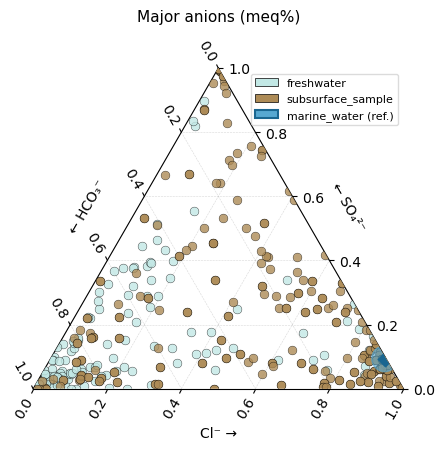

In [11]:
fig, ax = plt.subplots(figsize=(5, 4.5), subplot_kw={"projection": "ternary"})
_tern_plot(ax,
           water[["sample_group", "so4_pct", "hco3_pct", "cl_pct"]].dropna(),
           cols_trl=["so4_pct", "hco3_pct", "cl_pct"],
           labels_trl=["← SO₄²⁻", "← HCO₃⁻", "Cl⁻ →"],
           sw_trl=(SW_REF['so4_f'], SW_REF['hco3_f'], SW_REF['cl_f']),
           title="Major anions (meq%)",
           tick_pos="tick1")
plt.tight_layout()
plt.show()

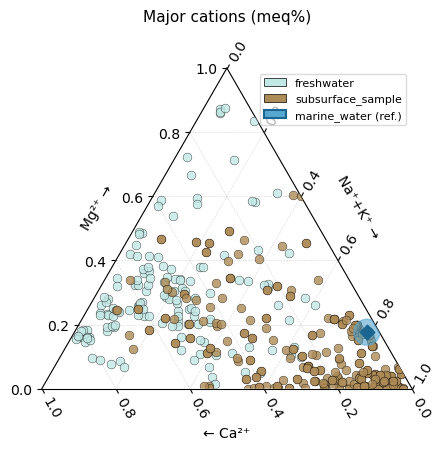

In [12]:
fig, ax = plt.subplots(figsize=(5, 4.5), subplot_kw={"projection": "ternary"})
_tern_plot(ax,
           water[["sample_group", "mg_pct", "ca_pct", "nak_pct"]].dropna(),
           cols_trl=["mg_pct", "ca_pct", "nak_pct"],
           labels_trl=["Mg²⁺ →", "← Ca²⁺", "Na⁺+K⁺ →"],
           sw_trl=(SW_REF['mg_f'], SW_REF['ca_f'], SW_REF['nak_f']),
           title="Major cations (meq%)",
           tick_pos="tick2")
plt.tight_layout()
plt.show()

In [13]:
SQ3 = np.sqrt(3);  H = SQ3/2
GAP = 0.25;  OX = 1 + GAP


def _cat_xy(ca, mg, nak):
    s = ca + mg + nak;  ca, mg, nak = ca/s, mg/s, nak/s
    return mg*0.5 + nak, mg*H


def _ani_xy(hco3, cl, so4):
    s = hco3 + cl + so4;  hco3, cl, so4 = hco3/s, cl/s, so4/s
    return OX + cl + so4*0.5, so4*H


def _diam_xy(xc, yc, xa, ya):
    xd = (xa + xc)/2 + (ya - yc)/(2*SQ3)
    return xd, SQ3*(xd - xc) + yc


dv_bot   = _diam_xy(1, 0, OX,   0)
dv_left  = _diam_xy(0, 0, OX,   0)
dv_right = _diam_xy(1, 0, OX+1, 0)
dv_top   = _diam_xy(0, 0, OX+1, 0)

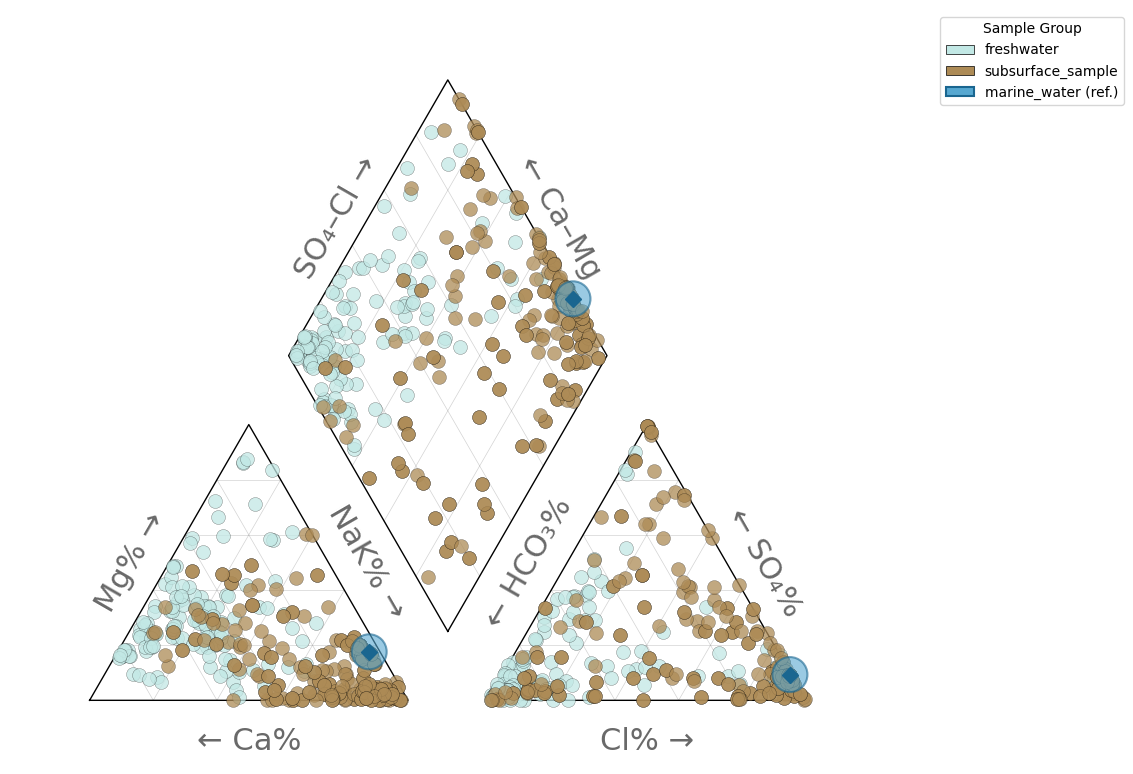

In [14]:
sub = water[["sample_group", "ca_pct", "mg_pct", "nak_pct", "so4_pct", "cl_pct", "hco3_pct"]].dropna()
sub = sub[(sub["ca_pct"]  + sub["mg_pct"]  + sub["nak_pct"])  > 0]
sub = sub[(sub["so4_pct"] + sub["cl_pct"]  + sub["hco3_pct"]) > 0]

fig, ax = plt.subplots(figsize=(11, 9))
ax.set_aspect('equal');  ax.axis('off')
kw_b = dict(color='k', linewidth=1, zorder=2)
kw_g = dict(color='gray', linewidth=0.5, alpha=0.35, zorder=1)

ax.plot([0, 1, 0.5, 0],          [0, 0, H, 0], **kw_b)
ax.plot([OX, OX+1, OX+0.5, OX], [0, 0, H, 0], **kw_b)
ax.plot([dv_bot[0], dv_right[0], dv_top[0], dv_left[0], dv_bot[0]],
        [dv_bot[1], dv_right[1], dv_top[1], dv_left[1], dv_bot[1]], **kw_b)

for f in [0.2, 0.4, 0.6, 0.8]:
    ax.plot([f,      0.5+0.5*f],  [0,    (1-f)*H], **kw_g)
    ax.plot([0.5*f,  1-0.5*f],   [f*H,  f*H],     **kw_g)
    ax.plot([1-f,    0.5*(1-f)], [0,    (1-f)*H],  **kw_g)
    ax.plot([OX+f,       OX+0.5*f+0.5], [0,    (1-f)*H], **kw_g)
    ax.plot([OX+0.5*f,   OX+1-0.5*f],   [f*H,  f*H],     **kw_g)
    ax.plot([OX+1-f,     OX+0.5*(1-f)], [0,    (1-f)*H],  **kw_g)
    ax.plot(*zip(_diam_xy(f, 0, OX, 0),   _diam_xy(f, 0, OX+1, 0)),   **kw_g)
    ax.plot(*zip(_diam_xy(0, 0, OX+f, 0), _diam_xy(1, 0, OX+f, 0)),   **kw_g)

kw_t = dict(ha='center', va='center', fontsize=22, color='dimgray')
ax.text(0.5,     -0.13, '← Ca%',    **kw_t)
ax.text(0.13,    H/2,   'Mg% →',    rotation=60,  **kw_t)
ax.text(0.87,    H/2,   'NaK% →',   rotation=-60, **kw_t)
ax.text(OX+0.5,  -0.13, 'Cl% →',    **kw_t)
ax.text(OX+0.13, H/2,   '← HCO₃%', rotation=60,  **kw_t)
ax.text(OX+0.87, H/2,   '← SO₄%',  rotation=-60, **kw_t)
ax.text((dv_left[0] + dv_top[0]) / 2 - 0.10,
        (dv_left[1] + dv_top[1]) / 2,
        'SO₄–Cl →', rotation=60,  **kw_t)
ax.text((dv_right[0] + dv_top[0]) / 2 + 0.10,
        (dv_right[1] + dv_top[1]) / 2,
        '← Ca–Mg',  rotation=-60, **kw_t)

groups_seen = []
for g in GROUPS:
    d = sub[sub["sample_group"] == g]
    if d.empty: continue
    col = color_sample_group[g]
    xc, yc = _cat_xy(d["ca_pct"].values, d["mg_pct"].values, d["nak_pct"].values)
    xa, ya = _ani_xy(d["hco3_pct"].values, d["cl_pct"].values, d["so4_pct"].values)
    xd, yd = _diam_xy(xc, yc, xa, ya)
    kws = dict(c=col, s=100, alpha=0.75, zorder=5, linewidths=0.2, edgecolors='k')
    ax.scatter(xc, yc, **kws);  ax.scatter(xa, ya, **kws);  ax.scatter(xd, yd, **kws)
    groups_seen.append(g)

sw_xc, sw_yc = _cat_xy(SW_REF['ca_f']*100, SW_REF['mg_f']*100, SW_REF['nak_f']*100)
sw_xa, sw_ya = _ani_xy(SW_REF['hco3_f']*100, SW_REF['cl_f']*100, SW_REF['so4_f']*100)
sw_xd, sw_yd = _diam_xy(sw_xc, sw_yc, sw_xa, sw_ya)
for cx, cy in [(sw_xc, sw_yc), (sw_xa, sw_ya), (sw_xd, sw_yd)]:
    ax.add_patch(Circle((cx, cy), 0.055, facecolor=_MCOL, edgecolor=_MEDGE,
                        linewidth=1.5, alpha=0.6, zorder=6))
    ax.plot(cx, cy, 'D', color=_MEDGE, markersize=8, zorder=7)
if 'marine_water' not in groups_seen:
    groups_seen.append('marine_water')

ax.legend(handles=[
    mpatches.Patch(
        facecolor=_MCOL if g == 'marine_water' else color_sample_group[g],
        edgecolor=_MEDGE if g == 'marine_water' else 'k',
        linewidth=1.5 if g == 'marine_water' else 0.5,
        label='marine_water (ref.)' if g == 'marine_water' else g,
    )
    for g in groups_seen
], loc='upper right', bbox_to_anchor=(1.28, 1.0),
   frameon=True, title='Sample Group', fontsize=10)

ax.set_xlim(-0.25, OX+1.25)
ax.set_ylim(-0.20, dv_top[1]+0.22)
plt.tight_layout()
plt.savefig("../outputs/piper_plot.svg", format="svg", transparent=True)
plt.show()

In [15]:
def _hull_area(x, y):
    pts = np.column_stack([x, y])
    pts = pts[~np.isnan(pts).any(axis=1)]
    if len(np.unique(pts, axis=0)) < 3:
        return np.nan
    try:
        return ConvexHull(pts).volume
    except Exception:
        return np.nan

In [16]:
results = {}
for g in ["freshwater", "subsurface_sample"]:
    d = sub[sub["sample_group"] == g]
    xc, yc = _cat_xy(d["ca_pct"].values, d["mg_pct"].values, d["nak_pct"].values)
    xa, ya = _ani_xy(d["hco3_pct"].values, d["cl_pct"].values, d["so4_pct"].values)
    xd, yd = _diam_xy(xc, yc, xa, ya)
    results[g] = dict(
        n         = len(d),
        hull_cat  = _hull_area(xc, yc),
        hull_ani  = _hull_area(xa, ya),
        hull_diam = _hull_area(xd, yd),
        sd_ca     = d["ca_pct"].std(),
        sd_mg     = d["mg_pct"].std(),
        sd_nak    = d["nak_pct"].std(),
        sd_so4    = d["so4_pct"].std(),
        sd_cl     = d["cl_pct"].std(),
        sd_hco3   = d["hco3_pct"].std(),
    )

rf, rs = results["freshwater"], results["subsurface_sample"]

print(f"{'Metric':<38} {'Freshwater':>12} {'Subsurface':>12} {'Ratio (S/F)':>12}")
print("─" * 78)

for lbl, key, denom in [
    ("Cation hull area  (% of triangle)", "hull_cat",  np.sqrt(3) / 4),
    ("Anion  hull area  (% of triangle)", "hull_ani",  np.sqrt(3) / 4),
    ("Diamond hull area (% of diamond)",  "hull_diam", (dv_right[0]-dv_left[0]) * (dv_top[1]-dv_bot[1]) / 2),
]:
    pf = rf[key] / denom * 100
    ps = rs[key] / denom * 100
    print(f"  {lbl:<36} {pf:>10.1f}%  {ps:>10.1f}%  {ps/pf:>10.2f}×")

print()
print(f"  {'Ion':<10} {'σ freshwater':>14} {'σ subsurface':>14}")
print("  " + "─" * 40)
for ion, k in [("Ca²⁺",  "sd_ca"),  ("Mg²⁺",  "sd_mg"),  ("Na⁺+K⁺", "sd_nak"),
               ("SO₄²⁻", "sd_so4"), ("Cl⁻",   "sd_cl"),  ("HCO₃⁻",  "sd_hco3")]:
    print(f"  {ion:<10} {rf[k]:>12.1f}%  {rs[k]:>12.1f}%")

print("\n  Hydrochemical facies (waterType_calc):")
for g in ["freshwater", "subsurface_sample"]:
    vc    = water[water["sample_group"] == g]["waterType_calc"].value_counts()
    probs = vc / vc.sum()
    H     = _entropy(probs, base=2)
    print(f"\n    {g}  ── {len(vc)} facies, Shannon H = {H:.2f} bits")
    for wt, n in vc.items():
        print(f"      {wt:<35}  n={n:>4}  ({n/vc.sum()*100:.1f}%)")

Metric                                   Freshwater   Subsurface  Ratio (S/F)
──────────────────────────────────────────────────────────────────────────────
  Cation hull area  (% of triangle)          64.8%        63.1%        0.97×
  Anion  hull area  (% of triangle)          86.7%        98.5%        1.13×
  Diamond hull area (% of diamond)           45.3%        82.3%        1.82×

  Ion          σ freshwater   σ subsurface
  ────────────────────────────────────────
  Ca²⁺               18.9%          16.9%
  Mg²⁺               17.3%          13.3%
  Na⁺+K⁺             15.6%          23.9%
  SO₄²⁻              17.0%          25.1%
  Cl⁻                21.1%          33.8%
  HCO₃⁻              27.0%          30.0%

  Hydrochemical facies (waterType_calc):

    freshwater  ── 5 facies, Shannon H = 0.93 bits
      Mixed waters                         n= 414  (77.1%)
      Bicarbonate waters                   n= 109  (20.3%)
      Chloride acidic waters               n=   5  (0.9%)
   

In [17]:
result = sample_table.copy()

_w = result[result["sample_group"].isin(["freshwater", "subsurface_sample"])].copy()
_w["hco3_meq"] = np.where(_w["alk_tot"].notna(),
                           _w["alk_tot"] / EW['HCO3'],
                           _w["alkMeqPerL_ALK"])
_w["so4_meq"] = _w["so4"] / EW['SO4']
_w["cl_meq"]  = _w["cl"]  / EW['Cl']

result.loc[_w.index, "water_type"] = _w.apply(classify_water_type, axis=1)

result.loc[result["sample_group"] == "marine_water", "water_type"] = "Chloride neutral waters"

print(result["water_type"].value_counts(dropna=False))
result.to_csv("../data_processed/sample_table.csv")

water_type
Mixed waters               621
NaN                        400
Chloride neutral waters    268
Bicarbonate waters         170
Chloride acidic waters      25
Sulfate waters              24
Sulfate-chloride waters      5
Name: count, dtype: int64
